# Histograms

Distributions have one theme-specific catch — the property cycle does not reach the outline style —
and a couple of habits that make them readable at 89 mm wide.

All data here is synthetic and all axis labels are deliberately generic — this notebook is about how a
figure is built and styled, not about any particular measurement.

In [1]:
%matplotlib inline

# Jupyter crops every inline preview with bbox_inches="tight". That defeats the exact column widths
# this package exists to guarantee, and because the themes sit the axes close to the canvas edge, the
# crop slices through the top and right spines. Turn it off so previews match the files jf.save() writes.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

# jf.save() reports what it wrote through the "journalfig" logger instead of printing. Raise that one
# logger -- a blanket logging.basicConfig(level="INFO") also switches on fontTools, which logs a dozen
# subsetting lines per PDF.
import logging

logging.basicConfig(format="%(message)s")
logging.getLogger("journalfig").setLevel(logging.INFO)

import numpy as np
import matplotlib.pyplot as plt

import journalfig as jf

# The themes render previews at 600 dpi, which makes every embedded image in a notebook large. This
# only touches the on-screen preview; jf.save() exports at savefig.dpi regardless.
PREVIEW_DPI = 150


def preview(journal, **kwargs):
    """Apply a theme, then drop the on-screen DPI so this notebook stays light."""
    jf.use(journal, **kwargs)
    plt.rcParams["figure.dpi"] = PREVIEW_DPI


rng = np.random.default_rng(0)
print("journalfig", jf.__version__, "| themes:", jf.JOURNALS)

journalfig 0.5.0 | themes: ('nature', 'aps', 'elsevier')


## A filled histogram

Give bars an explicit edge: at a single-column width, adjacent bars of the same colour merge into a
solid block without one.

Text(0, 0.5, 'Count')

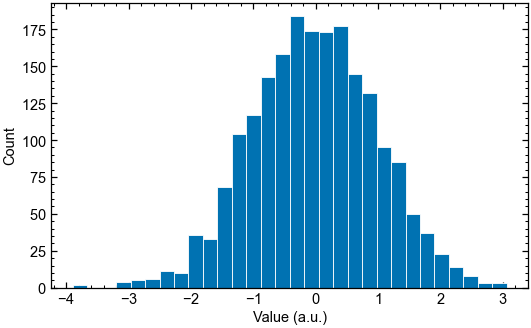

In [2]:
preview("elsevier")
sample = rng.normal(0, 1, 2000)

fig, ax = jf.subplots("elsevier", width="single")
ax.hist(sample, bins=30, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Value (a.u.)")
ax.set_ylabel("Count")

## Overlapping distributions

Outlines beat fills when distributions overlap. **One catch:** `histtype="step"` takes the colour from
the property cycle but *not* the linestyle, so every outline comes out solid and the panel is
unreadable in greyscale. Set the linestyle explicitly from `jf.LINESTYLE_CYCLE`.

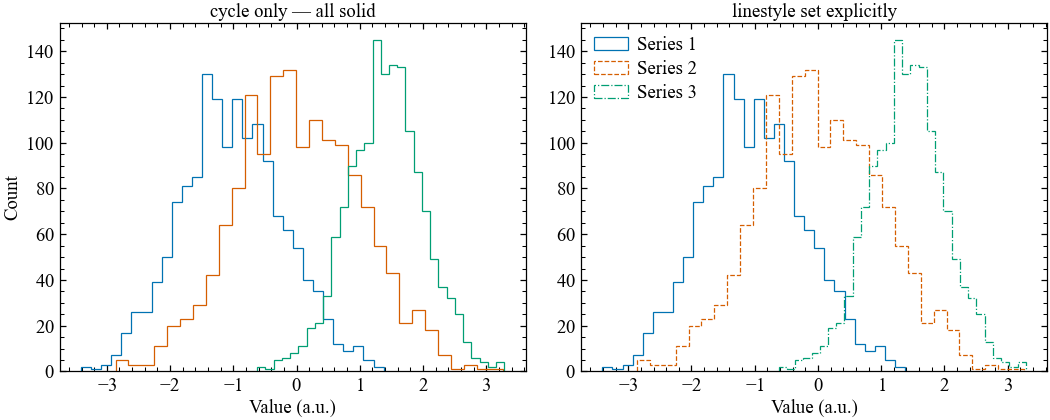

In [3]:
preview("aps")
samples = [rng.normal(loc, scale, 1500) for loc, scale in [(-1.0, 0.8), (0.0, 1.0), (1.4, 0.6)]]

fig, axs = jf.subplots("aps", 1, 2, width="double", ratio=0.4)
for i, s in enumerate(samples):
    axs[0].hist(s, bins=30, histtype="step")
    axs[1].hist(s, bins=30, histtype="step", linestyle=jf.LINESTYLE_CYCLE[i], label=f"Series {i + 1}")

axs[0].set_title("cycle only — all solid")
axs[1].set_title("linestyle set explicitly")
for ax in axs:
    ax.set_xlabel("Value (a.u.)")
axs[0].set_ylabel("Count")
axs[1].legend()

## Filled but overlapping

`histtype="stepfilled"` with `alpha` works when there are only two or three distributions. Remember
that transparency is preserved in PDF, SVG and PNG but flattened in EPS.

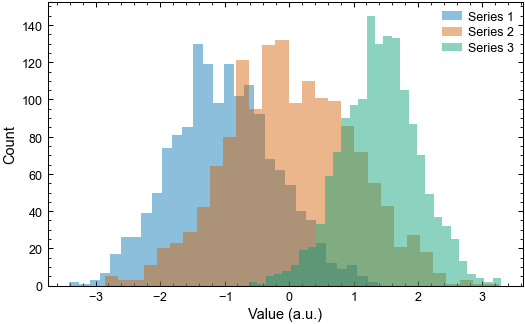

In [4]:
preview("nature")
fig, ax = jf.subplots("nature", width="single")
for i, s in enumerate(samples):
    ax.hist(s, bins=30, histtype="stepfilled", alpha=0.45, label=f"Series {i + 1}")
ax.set_xlabel("Value (a.u.)")
ax.set_ylabel("Count")
ax.legend()

## Shared bins

Comparing distributions requires identical bin edges. Computing them once from the pooled data is the
only way to guarantee it.

bin width: 0.2391


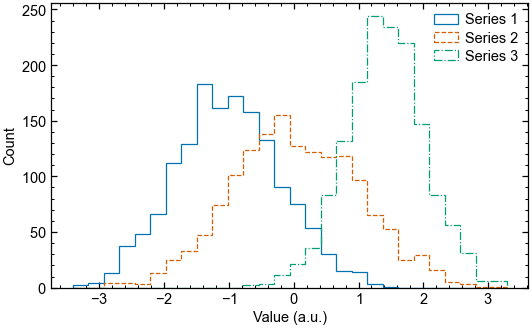

In [5]:
preview("elsevier")
edges = np.histogram_bin_edges(np.concatenate(samples), bins=28)

fig, ax = jf.subplots("elsevier", width="single")
for i, s in enumerate(samples):
    ax.hist(s, bins=edges, histtype="step", linestyle=jf.LINESTYLE_CYCLE[i], label=f"Series {i + 1}")
ax.set_xlabel("Value (a.u.)")
ax.set_ylabel("Count")
ax.legend()
print("bin width:", round(edges[1] - edges[0], 4))

## Densities, and unequal sample sizes

`density=True` normalises the area to one, which is what makes samples of different sizes comparable.

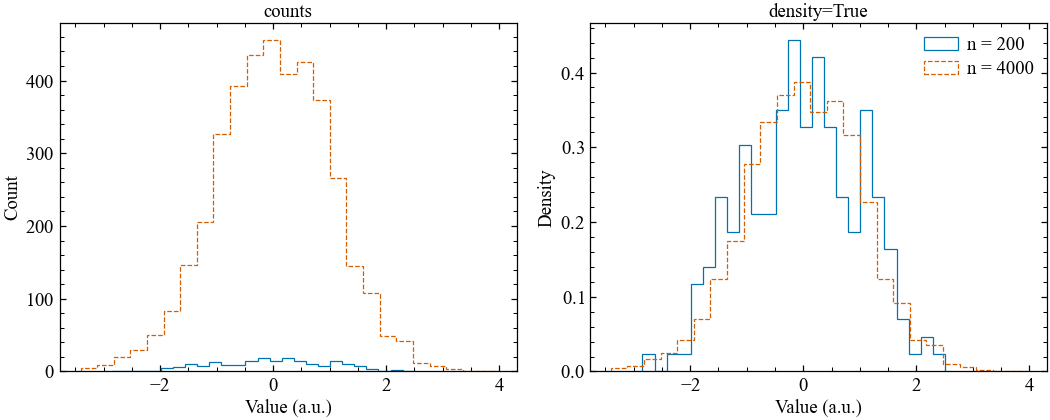

In [6]:
preview("aps")
small, large = rng.normal(0, 1, 200), rng.normal(0, 1, 4000)

fig, axs = jf.subplots("aps", 1, 2, width="double", ratio=0.4)
for ax, density in zip(axs, [False, True]):
    ax.hist(small, bins=25, histtype="step", density=density, label="n = 200")
    ax.hist(large, bins=25, histtype="step", linestyle="--", density=density, label="n = 4000")
    ax.set_xlabel("Value (a.u.)")
    ax.set_ylabel("Density" if density else "Count")
    ax.set_title("density=True" if density else "counts")
axs[1].legend()

## Hatching

Hatching distinguishes filled bars without any colour at all. The themes set `hatch.linewidth` so it
stays visible at print size rather than turning into a grey smear.

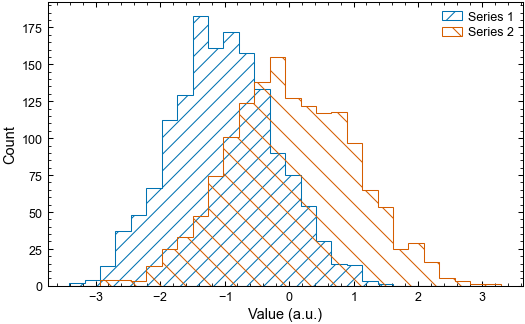

In [7]:
preview("nature")
fig, ax = jf.subplots("nature", width="single")
for i, (s, hatch) in enumerate(zip(samples[:2], ["///", "\\\\"])):
    ax.hist(s, bins=edges, histtype="stepfilled", facecolor="none", hatch=hatch,
            edgecolor=jf.COLOR_CYCLE[i], label=f"Series {i + 1}")
ax.set_xlabel("Value (a.u.)")
ax.set_ylabel("Count")
ax.legend()